# Notebook 6 — Efficiency Comparison
Compares privacy/utility trade-offs across all stages. Sensitive attribute: `fitness_level`.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

os.makedirs('../results', exist_ok=True)

with open('../results/privacy_metrics_complete.json') as f:
    all_results = json.load(f)

with open('../results/k_anonymity_metrics.json') as f:
    k_json = json.load(f)

with open('../results/l_diversity_metrics.json') as f:
    l_json = json.load(f)

with open('../results/t_closeness_metrics.json') as f:
    t_json = json.load(f)

print('✅ Loaded all results')

✅ Loaded all results


In [2]:
stages_data = all_results['stages']
stage_keys  = list(stages_data.keys())

original_records = stages_data['original']['dataset_stats']['total_records']

efficiency_rows = []
for s in stage_keys:
    sd = stages_data[s]
    records   = sd['dataset_stats']['total_records']
    groups    = sd['group_analysis']['total_groups']
    mean_size = sd['group_analysis']['mean_group_size']
    min_size  = sd['group_analysis']['min_group_size']

    retention = records / original_records * 100
    efficiency_rows.append({
        'Stage':             s,
        'Records':           records,
        'Groups':            groups,
        'Data Retention %':  round(retention, 2),
        'Data Loss %':       round(100 - retention, 2),
        'Mean Group Size':   round(mean_size, 2),
        'Min Group Size':    min_size,
        'Compression Ratio': round(original_records / groups, 2)
    })

efficiency_df = pd.DataFrame(efficiency_rows)
print('='*90)
print('EFFICIENCY METRICS ACROSS STAGES (sensitive attribute: fitness_level)')
print('='*90)
print(efficiency_df.to_string(index=False))

with open('../results/efficiency_metrics.json', 'w') as f:
    json.dump(efficiency_df.to_dict(orient='records'), f, indent=2)
print('\n✅ Saved: ../results/efficiency_metrics.json')

EFFICIENCY METRICS ACROSS STAGES (sensitive attribute: fitness_level)
      Stage  Records  Groups  Data Retention %  Data Loss %  Mean Group Size  Min Group Size  Compression Ratio
   original     7000    1001             100.0          0.0             6.99               1               6.99
k_anonymity     7000     143             100.0          0.0            48.95               1              48.95
l_diversity     7000     143             100.0          0.0            48.95               1              48.95
t_closeness     7000     143             100.0          0.0            48.95               1              48.95

✅ Saved: ../results/efficiency_metrics.json


In [3]:
privacy_rows = []
for s in stage_keys:
    sd = stages_data[s]
    row = {
        'Stage':                  s,
        'Sensitive Attribute':    'fitness_level',
        'Identity Protection':    'No' if s == 'original' else 'Yes',
        'Attribute Protection':   'No' if s in ('original', 'k_anonymity') else 'Yes',
        'Distribution Protection': 'Yes' if s == 't_closeness' else 'No'
    }

    if 'k_anonymity_metrics' in sd:
        row['K-Value']      = sd['k_anonymity_metrics']['k_value']
        row['K-Violations'] = sd['k_anonymity_metrics']['violations']
    else:
        row['K-Value'] = row['K-Violations'] = '-'

    if 'l_diversity_metrics' in sd:
        row['L-Value']      = sd['l_diversity_metrics']['l_value']
        row['L-Violations'] = sd['l_diversity_metrics']['violations']
    else:
        row['L-Value'] = row['L-Violations'] = '-'

    if 't_closeness_metrics' in sd:
        row['T-Threshold']  = sd['t_closeness_metrics']['t_threshold']
        row['T-Violations'] = sd['t_closeness_metrics']['violations']
        row['Mean TVD']     = round(sd['t_closeness_metrics']['mean_tvd'], 4)
    else:
        row['T-Threshold'] = row['T-Violations'] = row['Mean TVD'] = '-'

    privacy_rows.append(row)

privacy_df = pd.DataFrame(privacy_rows)
print('='*90)
print('PRIVACY PROTECTION LEVELS (sensitive attribute: fitness_level)')
print('='*90)
print(privacy_df.to_string(index=False))

with open('../results/privacy_protection_levels.json', 'w') as f:
    json.dump(privacy_df.to_dict(orient='records'), f, indent=2)
print('\n✅ Saved: ../results/privacy_protection_levels.json')

PRIVACY PROTECTION LEVELS (sensitive attribute: fitness_level)
      Stage Sensitive Attribute Identity Protection Attribute Protection Distribution Protection K-Value K-Violations L-Value L-Violations T-Threshold T-Violations Mean TVD
   original       fitness_level                  No                   No                      No       -            -       -            -           -            -        -
k_anonymity       fitness_level                 Yes                   No                      No       5            7       -            -           -            -        -
l_diversity       fitness_level                 Yes                  Yes                      No       -            -       3            8           -            -        -
t_closeness       fitness_level                 Yes                  Yes                     Yes       -            -       -            -        0.25           49   0.2617

✅ Saved: ../results/privacy_protection_levels.json


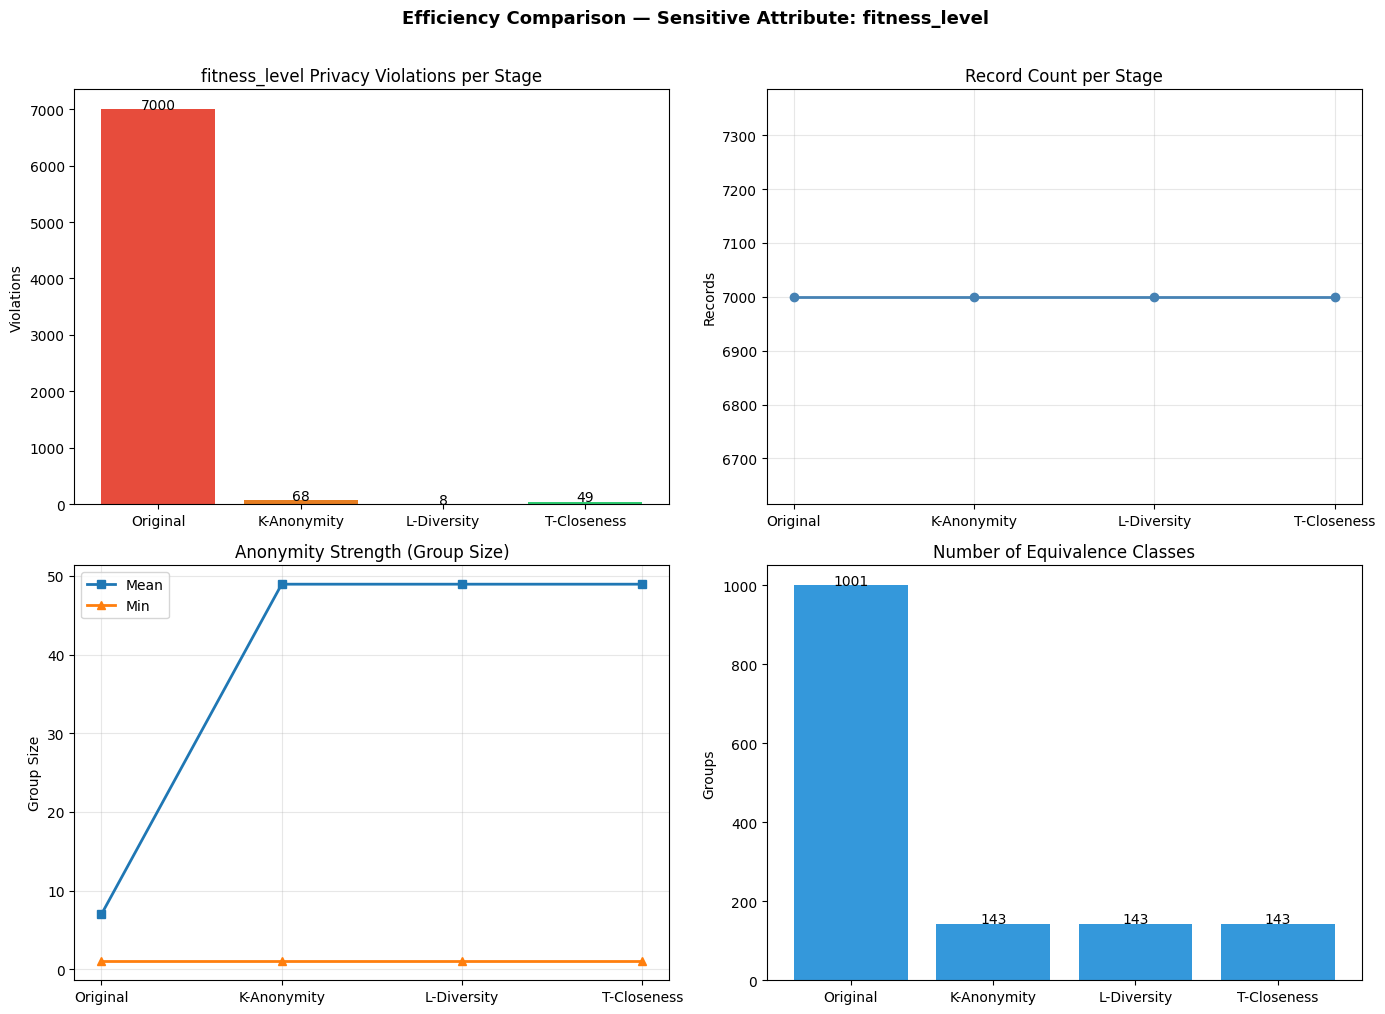

✅ Saved: ../results/efficiency_comparison.png


In [5]:
stages_short = ['Original', 'K-Anonymity', 'L-Diversity', 'T-Closeness']

violations = [
    original_records,
    k_json['k_anonymity_metrics']['fitness_level_l_violations'],
    l_json['l_diversity_metrics']['violations'],
    t_json['t_closeness_metrics']['violations']
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Violations
axes[0, 0].bar(stages_short, violations, color=['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71'])
axes[0, 0].set_title('fitness_level Privacy Violations per Stage')
axes[0, 0].set_ylabel('Violations')
for i, v in enumerate(violations):
    axes[0, 0].text(i, v + 2, str(v), ha='center')

# 2. Record retention
axes[0, 1].plot(stages_short, efficiency_df['Records'].values, marker='o', linewidth=2, color='steelblue')
axes[0, 1].set_title('Record Count per Stage')
axes[0, 1].set_ylabel('Records')
axes[0, 1].grid(True, alpha=0.3)

# 3. Group sizes
axes[1, 0].plot(stages_short, efficiency_df['Mean Group Size'].values, marker='s', label='Mean', linewidth=2)
axes[1, 0].plot(stages_short, efficiency_df['Min Group Size'].values,  marker='^', label='Min',  linewidth=2)
axes[1, 0].set_title('Anonymity Strength (Group Size)')
axes[1, 0].set_ylabel('Group Size')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Number of groups
axes[1, 1].bar(stages_short, efficiency_df['Groups'].values, color='#3498db')
axes[1, 1].set_title('Number of Equivalence Classes')
axes[1, 1].set_ylabel('Groups')
for i, v in enumerate(efficiency_df['Groups'].values):
    axes[1, 1].text(i, v + 1, str(int(v)), ha='center')

plt.suptitle('Efficiency Comparison — Sensitive Attribute: fitness_level', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/efficiency_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: ../results/efficiency_comparison.png')